##### Time Series Analysis (Temporal Trends)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy import stats

In [22]:
path= r"/Users/obanoyenracheal/Python/Practise/Temperature_Monthly_Data_1994_2024.csv"


In [23]:
df

,PARAMETER,YEAR,LAT,LON,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN,Decade
0,T2M,1994,19.5,87.500,24.18,24.52,26.47,28.02,29.03,28.80,27.97,27.64,28.03,27.73,26.81,24.29,26.97,1990
1,T2M,1994,19.5,88.125,24.21,24.44,26.43,27.99,29.00,28.78,28.04,27.60,27.87,27.78,26.82,24.44,26.96,1990
2,T2M,1994,19.5,88.750,24.25,24.44,26.33,27.97,28.92,28.72,28.00,27.61,27.79,27.80,26.86,24.61,26.95,1990
3,T2M,1994,19.5,89.375,24.18,24.43,26.20,27.94,28.84,28.71,27.95,27.62,27.79,27.79,26.91,24.65,26.93,1990
4,T2M,1994,19.5,90.000,24.07,24.39,26.05,27.92,28.86,28.75,27.95,27.51,27.82,27.77,26.96,24.56,26.89,1990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4180,T2M,2024,26.5,90.000,15.56,17.47,22.09,27.57,28.85,28.49,28.93,28.13,28.83,24.70,20.48,16.15,23.95,2020
4181,T2M,2024,26.5,90.625,16.14,17.96,22.61,27.82,29.00,28.97,29.57,28.67,29.47,25.16,21.11,16.52,24.43,2020
4182,T2M,2024,26.5,91.250,17.52,19.17,23.80,28.75,29.90,29.36,29.85,29.01,29.60,25.28,21.26,16.45,25.00,2020
4183,T2M,2024,26.5,91.875,17.34,18.94,23.80,28.13,29.50,28.95,29.45,28.83,29.38,25.03,21.23,16.35,24.75,2020


In [24]:
# Display data shape
print(f"\nData shape: {df.shape}")

#Check the column names
print(f"\nColumn names: {df.columns.tolist()}")


Data shape: (4185, 18)

Column names: ['PARAMETER', 'YEAR', 'LAT', 'LON', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN', 'Decade']


#### DATA OVERVIEW

In [25]:
#Data overview
print("TEMPERATURE TIME SERIES ANALYSIS (1994-2024)")

print("DATA OVERVIEW")
total_records = len(df)
print(f"Total records: {total_records}")

min_year = df['YEAR'].min()
max_year = df['YEAR'].max()
print(f"Years covered: {min_year} to {max_year}")

num_locations = df[['LAT', 'LON']].drop_duplicates().shape[0]
print(f"Unique locations: {num_locations}")

TEMPERATURE TIME SERIES ANALYSIS (1994-2024)
DATA OVERVIEW
Total records: 4185
Years covered: 1994 to 2024
Unique locations: 135


In [26]:
# Calculate annual average temperature (average across all locations per year)
annual_temps = df.groupby('YEAR')['ANN'].mean()
print("ANNUAL TEMPERATURE STATISTICS")

mean_temp = annual_temps.mean()
print(f"   Mean annual temperature (1994-2024): {mean_temp:.2f}°C")

min_temp = annual_temps.min()
min_year_val = annual_temps.idxmin()
print(f"   Minimum annual temperature: {min_temp:.2f}°C (Year: {min_year_val})")

max_temp = annual_temps.max()
max_year_val = annual_temps.idxmax()
print(f"   Maximum annual temperature: {max_temp:.2f}°C (Year: {max_year_val})")

std_temp = annual_temps.std()
print(f"   Standard deviation: {std_temp:.2f}°C")

ANNUAL TEMPERATURE STATISTICS
   Mean annual temperature (1994-2024): 25.66°C
   Minimum annual temperature: 25.18°C (Year: 2000)
   Maximum annual temperature: 26.15°C (Year: 1994)
   Standard deviation: 0.27°C


### LINEAR REGRESSION TREND ANALYSIS

In [27]:
# Extract years and temperatures as arrays
years = np.array(annual_temps.index)
temps = annual_temps.values

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(years, temps)

# Calculate trend per decade (10 years)
trend_per_decade = slope * 10

print("TREND ANALYSIS (Linear Regression)")
print(f"Slope: {slope:.6f}°C/year")
print(f"Temperature change per decade: {trend_per_decade:.3f}°C")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")

# Check statistical significance
if p_value < 0.05:
    print(f"Trend is STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print(f"Trend is NOT statistically significant (p ≥ 0.05)")

TREND ANALYSIS (Linear Regression)
Slope: -0.000185°C/year
Temperature change per decade: -0.002°C
R-squared: 0.0000
P-value: 9.7320e-01
Trend is NOT statistically significant (p ≥ 0.05)


In [28]:
# Create decade column
df['Decade'] = (df['YEAR'] // 10) * 10

# Calculate average temperature by decade
decadal_temps = df.groupby('Decade')['ANN'].mean()

print("TEMPERATURE BY DECADE")
for decade, temp in decadal_temps.items():
    print(f"   {int(decade)}s: {temp:.2f}°C")

TEMPERATURE BY DECADE
   1990s: 25.84°C
   2000s: 25.51°C
   2010s: 25.69°C
   2020s: 25.69°C


In [29]:
# Calculate average temperature for each month and identify seasonal patterns

# List of months
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 
          'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Calculate average temperature for each month
monthly_avg = []
for month in months:
    avg = df[month].mean()
    monthly_avg.append(avg)

# Find warmest and coldest months
warmest_idx = np.argmax(monthly_avg)
coldest_idx = np.argmin(monthly_avg)
warmest_month = months[warmest_idx]
coldest_month = months[coldest_idx]
max_monthly = max(monthly_avg)
min_monthly = min(monthly_avg)
seasonal_range = max_monthly - min_monthly

print("SEASONAL PATTERN (Average Monthly Temperatures)")
print(f"Warmest month: {warmest_month} ({max_monthly:.2f}°C)")
print(f"Coldest month: {coldest_month} ({min_monthly:.2f}°C)")
print(f"Seasonal range: {seasonal_range:.2f}°C")

SEASONAL PATTERN (Average Monthly Temperatures)
Warmest month: MAY (29.48°C)
Coldest month: JAN (18.87°C)
Seasonal range: 10.61°C


In [30]:
# Calculate year-on-year change
yoy_change = annual_temps.diff()

# Count warming and cooling years
warming_years = (yoy_change > 0).sum()
cooling_years = (yoy_change < 0).sum()
total_years = len(yoy_change) - 1

# Calculate percentages
warming_pct = (warming_years / total_years) * 100
cooling_pct = (cooling_years / total_years) * 100

print("\n6. YEAR-ON-YEAR TEMPERATURE CHANGE")
print(f"   Warming years: {warming_years} ({warming_pct:.1f}%)")
print(f"   Cooling years: {cooling_years} ({cooling_pct:.1f}%)")

# Average increases and decreases
avg_increase = yoy_change[yoy_change > 0].mean()
avg_decrease = yoy_change[yoy_change < 0].mean()

print(f"   Avg increase (warming years): {avg_increase:.3f}°C")
print(f"   Avg decrease (cooling years): {avg_decrease:.3f}°C")


6. YEAR-ON-YEAR TEMPERATURE CHANGE
   Warming years: 18 (60.0%)
   Cooling years: 12 (40.0%)
   Avg increase (warming years): 0.200°C
   Avg decrease (cooling years): -0.326°C


### FORECAST ANALYSIS (3-YEAR MOVING AVERAGE FORECAST)

In [31]:
print("\n7. FORECAST ANALYSIS (3-Year Moving Average Method)")

# Calculate 3-year moving average
window = 3
moving_avg = annual_temps.rolling(window=window).mean()

# Get the last 3 values to use for forecasting
last_3_values = annual_temps.tail(3).values

print(f"\n   Last 3 years of data (for reference):")
for i, year in enumerate(annual_temps.tail(3).index):
    print(f"   Year {year}: {annual_temps[year]:.2f}°C")

# Forecast next 5 years using moving average
# Each forecast is the average of the previous 3 years
forecast_years = np.array([2025, 2026, 2027, 2028, 2029])
forecast_temps = []

# Start with last 3 values
recent_values = list(last_3_values)

print(f"\n   Forecasted temperatures (2025-2029):")
for year in forecast_years:
    # Average of the last 3 values
    forecast_value = np.mean(recent_values[-3:])
    forecast_temps.append(forecast_value)
    print(f"   Year {year}: {forecast_value:.2f}°C")
    
    # Add the forecast to the recent values for next iteration
    recent_values.append(forecast_value)

forecast_temps = np.array(forecast_temps)

# Calculate uncertainty (standard deviation of actual year-to-year changes)
yearly_changes = annual_temps.diff().dropna()
std_change = np.std(yearly_changes)
confidence_interval = 1.96 * std_change  # 95% confidence

print(f"\n   Forecast details:")
print(f"   - Method: 3-Year Moving Average")
print(f"   - How it works: Each year's forecast = average of previous 3 years")
print(f"   - Uncertainty (95% confidence interval): ±{confidence_interval:.2f}°C")
print(f"   - This captures natural year-to-year variability")


7. FORECAST ANALYSIS (3-Year Moving Average Method)

   Last 3 years of data (for reference):
   Year 2022: 25.50°C
   Year 2023: 26.07°C
   Year 2024: 25.84°C

   Forecasted temperatures (2025-2029):
   Year 2025: 25.80°C
   Year 2026: 25.91°C
   Year 2027: 25.85°C
   Year 2028: 25.85°C
   Year 2029: 25.87°C

   Forecast details:
   - Method: 3-Year Moving Average
   - How it works: Each year's forecast = average of previous 3 years
   - Uncertainty (95% confidence interval): ±0.61°C
   - This captures natural year-to-year variability


### VISUALISATION


✓ Visualization saved: temperature_timeseries_analysis.png


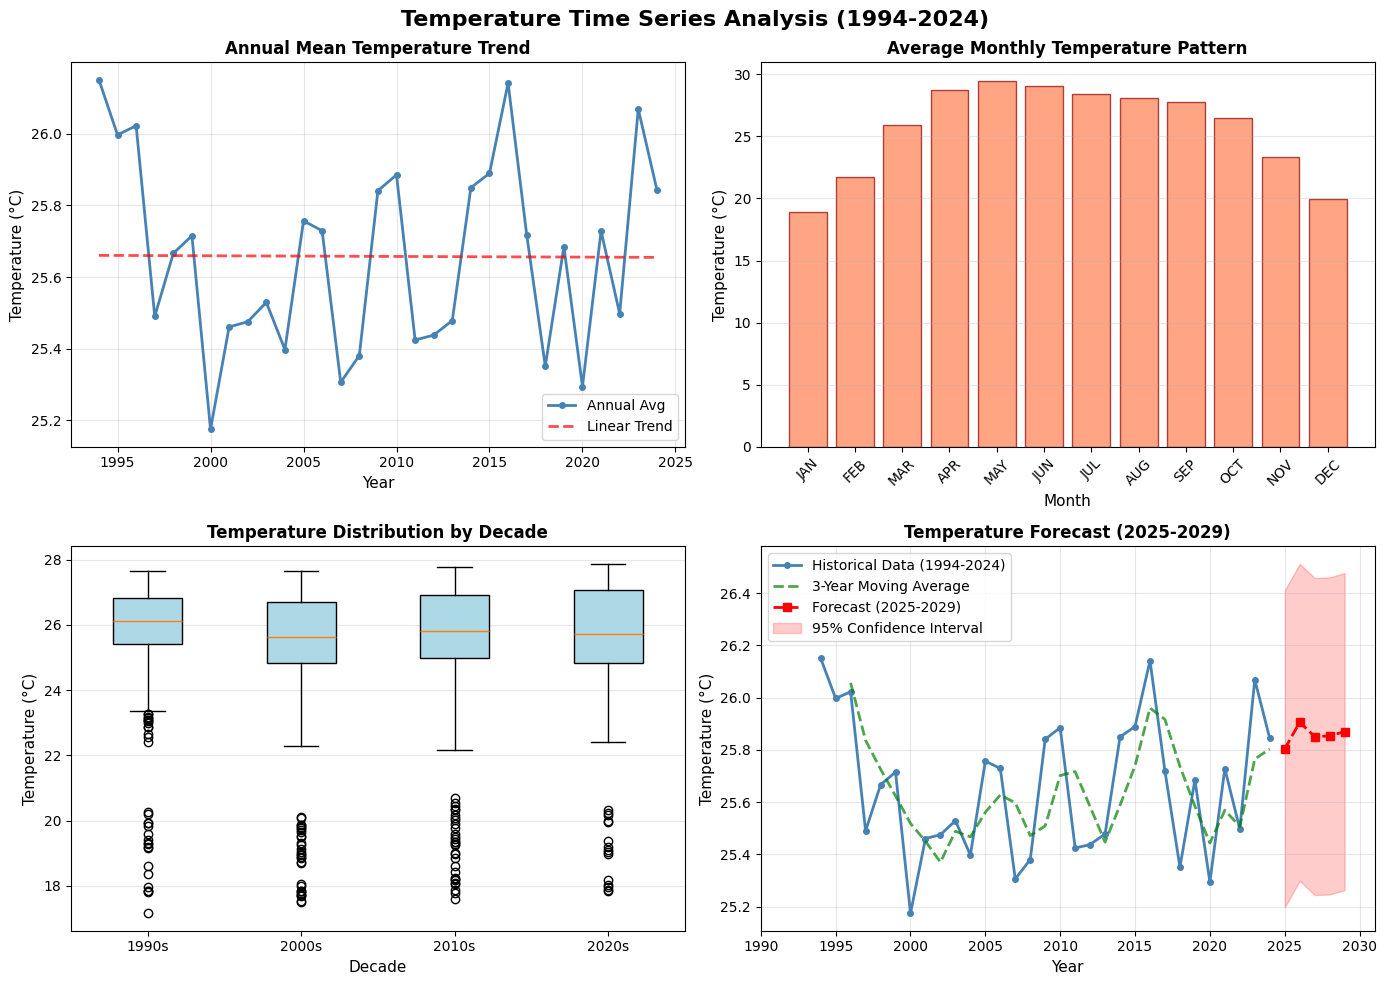

In [32]:
# Create a figure with 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Temperature Time Series Analysis (1994-2024)', 
             fontsize=16, fontweight='bold')


# ===== PLOT 1: Annual Temperature Trend =====
ax1 = axes[0, 0]

# Plot annual temperatures
ax1.plot(years, temps, 'o-', color='steelblue', linewidth=2, 
         markersize=4, label='Annual Avg')

# Add linear regression line
z = np.polyfit(years, temps, 1)
p = np.poly1d(z)
ax1.plot(years, p(years), '--', color='red', linewidth=2, 
         alpha=0.7, label='Linear Trend')

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.set_title('Annual Mean Temperature Trend', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()


# ===== PLOT 2: Monthly Seasonal Pattern =====
ax2 = axes[0, 1]

month_nums = np.arange(1, 13)
ax2.bar(month_nums, monthly_avg, color='coral', alpha=0.7, edgecolor='darkred')

ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Temperature (°C)', fontsize=11)
ax2.set_title('Average Monthly Temperature Pattern', fontweight='bold')
ax2.set_xticks(month_nums)
ax2.set_xticklabels(months, rotation=45)
ax2.grid(True, alpha=0.3, axis='y')


# ===== PLOT 3: Temperature Distribution by Decade =====
ax3 = axes[1, 0]

decades = sorted(df['Decade'].unique())
decade_data = []
for decade in decades:
    decade_temps = df[df['Decade'] == decade]['ANN'].values
    decade_data.append(decade_temps)

decade_labels = [f"{int(d)}s" for d in decades]

bp = ax3.boxplot(decade_data, tick_labels=decade_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax3.set_xlabel('Decade', fontsize=11)
ax3.set_ylabel('Temperature (°C)', fontsize=11)
ax3.set_title('Temperature Distribution by Decade', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')


# ===== PLOT 4: Forecast =====
ax4 = axes[1, 1]

# Plot historical data
ax4.plot(years, temps, 'o-', color='steelblue', linewidth=2, 
         markersize=4, label='Historical Data (1994-2024)')

# Plot 3-year moving average
ax4.plot(years, moving_avg, '--', color='green', linewidth=2, 
         alpha=0.7, label='3-Year Moving Average')

# Plot forecast
ax4.plot(forecast_years, forecast_temps, 's--', color='red', linewidth=2, 
         markersize=6, label='Forecast (2025-2029)')

# Add confidence interval (shaded area)
upper_bound = forecast_temps + confidence_interval
lower_bound = forecast_temps - confidence_interval
ax4.fill_between(forecast_years, lower_bound, upper_bound, 
                 color='red', alpha=0.2, label='95% Confidence Interval')

ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Temperature (°C)', fontsize=11)
ax4.set_title('Temperature Forecast (2025-2029)', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_xlim(1990, 2031)


# Save the figure
plt.tight_layout()
plt.savefig('temperature_timeseries_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: temperature_timeseries_analysis.png")

# Display the plot
plt.show()

In [33]:
print("CONCLUSIONS")
print("="*70)

print("\n1. TREND ANALYSIS RESULT:")
if p_value < 0.05:
    print(f"   Thsere IS a significant temperature trend: {trend_per_decade:.3f}°C per decade")
else:
    print(f"   There is NO significant temperature trend")
    print(f"   The trend is {trend_per_decade:.3f}°C per decade (not statistically significant)")

print("\n2. TEMPERATURE STABILITY:")
range_temp = max_temp - min_temp
print(f"   Temperature range over 30 years: {range_temp:.2f}°C")
print(f"   This indicates stable/consistent climate")

print("\n3. SEASONAL PATTERN:")
print(f"   Clear seasonal variation of {seasonal_range:.2f}°C")
print(f"   Typical of tropical/monsoon climate regions")

print("\n4. YEAR-TO-YEAR VARIABILITY:")
print(f"   {warming_pct:.0f}% of years show warming")
print(f"   {cooling_pct:.0f}% of years show cooling")
print(f"   This is natural variability without systematic trend")

print("\n5. FORECAST FOR 2025-2029:")
print(f"   Average forecasted temperature: {forecast_temps.mean():.2f}°C")
print(f"   Range: {forecast_temps.min():.2f}°C to {forecast_temps.max():.2f}°C")
print(f"   Uncertainty: ±{confidence_interval:.2f}°C (95% confidence)")
print(f"   Note: Forecast assumes current linear trend continues")


CONCLUSIONS

1. TREND ANALYSIS RESULT:
   There is NO significant temperature trend
   The trend is -0.002°C per decade (not statistically significant)

2. TEMPERATURE STABILITY:
   Temperature range over 30 years: 0.98°C
   This indicates stable/consistent climate

3. SEASONAL PATTERN:
   Clear seasonal variation of 10.61°C
   Typical of tropical/monsoon climate regions

4. YEAR-TO-YEAR VARIABILITY:
   60% of years show warming
   40% of years show cooling
   This is natural variability without systematic trend

5. FORECAST FOR 2025-2029:
   Average forecasted temperature: 25.86°C
   Range: 25.80°C to 25.91°C
   Uncertainty: ±0.61°C (95% confidence)
   Note: Forecast assumes current linear trend continues
